## Beating Angle Definition

The beating angle quantifies the angular excursion of a cilium during its beat cycle.  
Following the geometric formulation inspired by Papon *et al.*, the angle is defined
using three points on the cilium:


Let the Euclidean distances between these points be defined as:

$$
a = \| P_0 P_1 \|,\quad
b = \| P_0 P_2 \|,\quad
c = \| P_1 P_2 \|
$$

The beating angle $$\theta$$ at the base point $$P_0$$ is computed using the law of cosines:

$$
\theta
=
\cos^{-1}
\left(
\frac{a^2 + b^2 - c^2}{2ab}
\right)
$$

The angle $$\theta$$ is expressed in degrees.


In [47]:
import cv2
import numpy as np
import os
import pandas as pd
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

VIDEO_DIR = r"C:\\Users\\Ssehra\\Desktop\\PCD\\Data_videos"
OUT_DIR   = r"C:\\Users\\Ssehra\\Desktop\\PCD\\output\\bending_angle_v2"
os.makedirs(OUT_DIR, exist_ok=True)
MAX_FRAMES = 400
VALID_EXTS = ('.mp4', '.avi', '.mov')
FEATURE_COLS = ['mean_angle_deg','std_angle_deg','mean_dist_px','linearity_ratio','frames_tracked']
print(VIDEO_DIR)
print(OUT_DIR)

C:\\Users\\Ssehra\\Desktop\\PCD\\Data_videos
C:\\Users\\Ssehra\\Desktop\\PCD\\output\\bending_angle_v2


In [48]:
from collections import Counter
from cv2 import blur
import cv2
import numpy as np

def computebeatangle(p0, p1, p2):
    """Law of Cosines to find angle at P0 between P1 and P2"""
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    
    a = np.linalg.norm(p0 - p1)
    b = np.linalg.norm(p0 - p2)
    c = np.linalg.norm(p1 - p2)
    
    denom = max(2.0 * a * b, 1e-8)
    costheta = np.clip((a**2 + b**2 - c**2) / denom, -1.0, 1.0)
    
    return float(np.degrees(np.arccos(costheta)))

def auto_detect_roi(videopath, maxframes=300):
    cap = cv2.VideoCapture(videopath)
    frames = []
    
    count = 0
    while count < maxframes:
        ok, frame = cap.read()
        if not ok: break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray.astype(np.float32))
        count += 1
    cap.release()
    
    if len(frames) < 10: return None
    
    # Calculate motion variance to find where the cilium is moving
    videostack = np.stack(frames, axis=0)
    stdimg = np.std(videostack, axis=0)
    stdimgnorm = cv2.normalize(stdimg, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Threshold to find the main motion blob
    _, binaryfan = cv2.threshold(stdimgnorm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Find bounding box of the moving area
    ys, xs = np.where(binaryfan > 0)
    if len(xs) == 0: return None
    bottom_idx = np.argmax(ys)
    p0 = (xs[bottom_idx], ys[bottom_idx])  # Base point of cilium
    
    # Add a 10 pixel pad around the motion
    pad = 10
    x1 = max(0, np.min(xs) - pad)
    y1 = max(0, np.min(ys) - pad)
    x2 = min(videostack.shape[2], np.max(xs) + pad) # Width
    y2 = min(videostack.shape[1], np.max(ys) + pad) # Height
    
    return [x1, y1, x2, y2]


In [49]:
def process_dynamic_automated(videopath, out_dir, maxframes=300):
    """Measures the primary beating angle by projecting motion onto its dominant axis, rejecting PCD dyskinetic twirling."""
    roibox = auto_detect_roi(videopath, maxframes)
    if roibox is None: 
        return np.nan, np.nan, 0.0, np.nan, 0
        
    x1, y1, x2, y2 = roibox
    cap = cv2.VideoCapture(videopath)
    frames = []
    
    count = 0
    while count < maxframes:
        ok, frame = cap.read()
        if not ok: break
        roi = frame[y1:y2, x1:x2]
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        frames.append(gray.astype(np.float32))
        count += 1
    cap.release()
    
    if len(frames) < 10: return np.nan, np.nan, 0.0, np.nan, 0
    
    # 1. Create the base anchor using the standard deviation fan
    videostack = np.stack(frames, axis=0)
    std_img = np.std(videostack, axis=0)
    std_norm = cv2.normalize(std_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    std_norm_blurred = cv2.GaussianBlur(std_norm, (5, 5), 0)
    _, motion_mask = cv2.threshold(std_norm_blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    ys, xs = np.where(motion_mask > 0)
    if len(ys) == 0:
      return np.nan, np.nan, 0.0, np.nan, 0

    # Base anchor point (bottom-center of motion fan)
    p0 = np.array([np.median(xs), np.max(ys)], dtype=np.float32)
    
    # 2. Track the "center of mass" of motion in each individual frame
    # Instead of finding the "furthest point" which jumps around, we find the core of the moving shaft
    mean_img = np.mean(videostack, axis=0)
    
    valid_angles = []
    tips_x, tips_y = [], []
    
    for gray in frames:
        diff = cv2.absdiff(gray, mean_img)
        # Only look at motion inside the known fan
        clean_diff = cv2.bitwise_and(diff, diff, mask=motion_mask)
        
        # Take the top 10% brightest pixels in this frame (the moving shaft/tip)
        threshold_val = np.percentile(clean_diff[clean_diff > 0], 90) if np.any(clean_diff > 0) else 255
        fys, fxs = np.where(clean_diff >= threshold_val)
        
        if len(fxs) > 0:
            # The tip is the center of the brightest moving chunk, not a rogue distant pixel
            tip_x = np.median(fxs)
            tip_y = np.median(fys)
            
            dist = np.sqrt((tip_x - p0[0])**2 + (p0[1] - tip_y)**2)
            
            # Reject noise that happens directly at the base
            if dist > 10:
                tips_x.append(tip_x)
                tips_y.append(tip_y)
                angle = np.degrees(np.arctan2(tip_x - p0[0], p0[1] - tip_y))
                valid_angles.append(angle)

    
    # Use standard 5th and 95th to chop off rogue twitches
    leftbound = np.percentile(valid_angles, 5)
    rightbound = np.percentile(valid_angles, 95)
    
    raw_angle = float(abs(rightbound - leftbound))
    if raw_angle > 180: raw_angle = 360 - raw_angle
    
    # Calculates how much the tips deviate from a flat plane
    # If the variance in X is similar to the variance in Y, it's circular (PCD).
    # If the variance in X is huge and Y is small, it's a flat planar stroke (Healthy).
    tips_pts = np.column_stack((tips_x, tips_y))
    linearity_ratio = np.nan
    if len(tips_pts) > 2:
        cov_matrix = np.cov(tips_pts, rowvar=False)
        eigenvalues, _ = np.linalg.eigh(cov_matrix)
        
        # Ratio of primary axis to secondary axis
        linearity_ratio = max(eigenvalues) / (min(eigenvalues) + 1e-6)
        
        # If the linearity ratio is very low (e.g. < 3), the motion is circular/dyskinetic.
        # We mathematically squish the angle down because it's not a true planar power stroke.
        if linearity_ratio < 3.0:
            final_angle = raw_angle * (linearity_ratio / 3.0)
        else:
            final_angle = raw_angle
    else:
        final_angle = raw_angle

    std_angle_deg = float(np.std(valid_angles))

    # Clean up output coordinates for drawing
    p1_idx = np.argmin(np.abs(valid_angles - leftbound))
    p2_idx = np.argmin(np.abs(valid_angles - rightbound))
    
    p1 = np.array([tips_x[p1_idx], tips_y[p1_idx]])
    p2 = np.array([tips_x[p2_idx], tips_y[p2_idx]])
    dist_val = float(np.linalg.norm(p1 - p2))
    
    debug_img = cv2.cvtColor(std_norm, cv2.COLOR_GRAY2BGR)
    cv2.circle(debug_img, (int(p0[0]), int(p0[1])), 3, (0, 255, 0), -1)
    cv2.circle(debug_img, (int(p1[0]), int(p1[1])), 3, (0, 0, 255), -1)
    cv2.circle(debug_img, (int(p2[0]), int(p2[1])), 3, (255, 0, 0), -1)
    
    basename = os.path.splitext(os.path.basename(videopath))[0]
    cv2.imwrite(os.path.join(out_dir, f"{basename}_autotrack.png"), debug_img)
    
    return final_angle, std_angle_deg, dist_val, linearity_ratio, len(valid_angles)

#hi keep track of which folder each video came from
def group_from_path(path):
    s = str(path).lower().replace("\\", "/")

    if "control_healthy" in s:
        return "control_healthy"
    elif "oss_healthy_data" in s:
        return "oss_healthy_data"
    elif "oss_pcd_data_collected_diff_sources" in s:
        return "oss_pcd_data_collected_diff_sources"
    elif "atp_treatment" in s:
        return "atp_treatment"
    elif "nac_treatment" in s:
        return "nac_treatment"
    elif "temperature_treatment" in s:
        return "temperature_treatment"
    elif "terbutaline_treatment" in s:
        return "terbutaline_treatment"
    elif "tfp_treatment" in s:
        return "tfp_treatment"
    else:
        return "unknown"

def label_from_path(path):
    s = str(path).lower().replace("\\", "/")

    if "control_healthy" in s or "oss_healthy_data" in s:
        return 0

    elif "oss_pcd_data_collected_diff_sources" in s:
        return 1

    elif (
        "atp_treatment" in s or
        "nac_treatment" in s or
        "temperature_treatment" in s or
        "terbutaline_treatment" in s or
        "tfp_treatment" in s
    ):
        return np.nan

    else:
        return np.nan

videodir = r"C:\Users\Ssehra\Desktop\PCD\Data_videos"

out_dir = r"C:\Users\Ssehra\Desktop\PCD\output\bending_angle_v2"
os.makedirs(out_dir, exist_ok=True) 

# Execution loop 
VIDEO_EXTS = ('.mp4', '.avi', '.mov', '.mkv', '.wmv', '.m4v')

all_video_paths = []
for root, dirs, files in os.walk(videodir):
    for fname in files:
        if fname.lower().endswith(VIDEO_EXTS):
            all_video_paths.append(os.path.join(root, fname))

print(f"Total video files found: {len(all_video_paths)}")

summaryrows = []

for path in all_video_paths:
    fname = os.path.basename(path)

    try:
        angle, std_angle, dist, lin_ratio, frames_tracked = process_dynamic_automated(
            path, out_dir
        )

        label = label_from_path(path)        
        group = group_from_path(path)         

        if frames_tracked >= 10 and not np.isnan(angle):
            summaryrows.append({
                'video': os.path.splitext(fname)[0],
                'full_path': path,             
                'group': group,               
                'label': label,               
                'mean_angle_deg': angle,
                'std_angle_deg': std_angle,
                'mean_dist_px': dist,
                'linearity_ratio': lin_ratio,
                'frames_tracked': frames_tracked
            })
            print(f"Result {fname}: {angle:.2f} degrees | group={group} | label={label}")
        else:
            print(f"Skipped {fname}: not enough threshold-valid frames")

    except Exception as e:
        print(f"Error processing {fname}: {e}")

summary_df = pd.DataFrame(summaryrows)
summary_csv = os.path.join(out_dir, "automated_angles_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print(f"Saved summary to: {summary_csv}")
print(summary_df.head())

Total video files found: 391
Result m1p3_atp0_1.avi: 67.96 degrees | group=atp_treatment | label=nan
Result m1p3_atp0_2.avi: 15.72 degrees | group=atp_treatment | label=nan
Result m1p3_atp0_3.avi: 14.19 degrees | group=atp_treatment | label=nan
Result m1p3_atp1000_1.avi: 32.06 degrees | group=atp_treatment | label=nan
Result m1p3_atp1000_2.avi: 100.77 degrees | group=atp_treatment | label=nan
Result m1p3_atp1000_3.avi: 45.97 degrees | group=atp_treatment | label=nan
Result m1p3_atp100_1.avi: 18.53 degrees | group=atp_treatment | label=nan
Result m1p3_atp100_2.avi: 48.46 degrees | group=atp_treatment | label=nan
Result m1p3_atp100_3.avi: 36.75 degrees | group=atp_treatment | label=nan
Result m1p3_atp100_4.avi: 28.86 degrees | group=atp_treatment | label=nan
Result m1p3_atp10_1.avi: 49.32 degrees | group=atp_treatment | label=nan
Result m1p3_atp10_2.avi: 62.85 degrees | group=atp_treatment | label=nan
Result m1p3_atp10_3.avi: 84.91 degrees | group=atp_treatment | label=nan
Result m1p3_at

Loading Bending Angle Data...
Training Models...


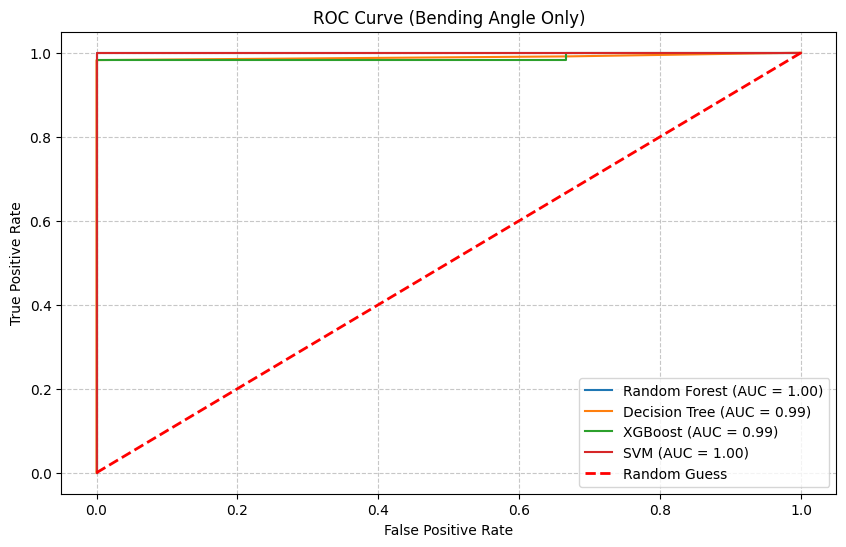


FINAL RESULTS: BENDING ANGLE MODELS
Random Forest:
  Accuracy:    0.99
  AUC:         1.00
  Sensitivity: 0.99
  Specificity: 1.00

Decision Tree:
  Accuracy:    0.97
  AUC:         0.99
  Sensitivity: 0.99
  Specificity: 0.33

XGBoost:
  Accuracy:    0.98
  AUC:         0.99
  Sensitivity: 1.00
  Specificity: 0.33

SVM:
  Accuracy:    0.97
  AUC:         1.00
  Sensitivity: 1.00
  Specificity: 0.00



In [50]:
# Machine Learning Pipeline for Bending Angle

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

print("Loading Bending Angle Data...")

# 1. Load Data
csv_path = r"C:\Users\Ssehra\Desktop\PCD\output\bending_angle_v2\automated_angles_summary.csv" 
df = pd.read_csv(csv_path)

# 2. Assign Labels based on filename (since the CSV doesn't have a label column)
def get_label(filename):
    if "healthy" in str(filename).lower() or "ciliavideo" in str(filename).lower():
        return 0 # Healthy
    else:
        return 1 # PCD

video_col = 'video_name' if 'video_name' in df.columns else 'video'
angle_col = 'angle_deg' if 'angle_deg' in df.columns else 'mean_angle_deg'

if video_col not in df.columns:
    raise ValueError(f"Could not find a video-name column. Available columns: {list(df.columns)}")
if angle_col not in df.columns:
    raise ValueError(f"Could not find an angle column. Available columns: {list(df.columns)}")

df['label'] = df[video_col].apply(get_label)

# 3. Drop failures/NaNs and setup X and y
FEATURE_COLS = [
    'mean_angle_deg',
    'std_angle_deg',
    'mean_dist_px',
    'linearity_ratio',
    'frames_tracked'
]

df = df.dropna(subset=FEATURE_COLS).copy()
X = df[FEATURE_COLS].copy()
y = df['label'].values

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Scale Data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Helper Functions
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return sensitivity, specificity

def plot_roc_auc(model, X_test, y_test, model_name, ax):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict(X_test)
        
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    return roc_auc, y_prob

# --- Plot Setup ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('ROC Curve (Bending Angle Only)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.grid(True, linestyle='--', alpha=0.7)

results = {}

print("Training Models...")

# ====================================================
# 1. Random Forest
# ====================================================
rf_param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 3, 5]}
rf_model = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_model, rf_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc, _ = plot_roc_auc(best_rf, X_test, y_test, 'Random Forest', ax)
rf_sens, rf_spec = compute_sensitivity_specificity(y_test, rf_pred)
results['Random Forest'] = {'Accuracy': rf_acc, 'AUC': rf_auc, 'Sensitivity': rf_sens, 'Specificity': rf_spec}


# ====================================================
# 2. Decision Tree
# ====================================================
dt_param_grid = {'max_depth': [None, 3, 5], 'min_samples_split': [2, 5]}
dt_model = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt_model, dt_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
dt_pred = best_dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_auc, _ = plot_roc_auc(best_dt, X_test, y_test, 'Decision Tree', ax)
dt_sens, dt_spec = compute_sensitivity_specificity(y_test, dt_pred)
results['Decision Tree'] = {'Accuracy': dt_acc, 'AUC': dt_auc, 'Sensitivity': dt_sens, 'Specificity': dt_spec}


# ====================================================
# 3. XGBoost
# ====================================================
xgb_param_grid = {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=44)
xgb_grid = GridSearchCV(xgb_model, xgb_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
xgb_pred = best_xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc, _ = plot_roc_auc(best_xgb, X_test, y_test, 'XGBoost', ax)
xgb_sens, xgb_spec = compute_sensitivity_specificity(y_test, xgb_pred)
results['XGBoost'] = {'Accuracy': xgb_acc, 'AUC': xgb_auc, 'Sensitivity': xgb_sens, 'Specificity': xgb_spec}


# ====================================================
# 4. SVM (RBF)
# ====================================================
svm_param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale']}
svm_model = SVC(probability=True, random_state=42)
svm_grid = GridSearchCV(svm_model, svm_param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_
svm_pred = best_svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)
svm_auc, _ = plot_roc_auc(best_svm, X_test, y_test, 'SVM', ax)
svm_sens, svm_spec = compute_sensitivity_specificity(y_test, svm_pred)
results['SVM'] = {'Accuracy': svm_acc, 'AUC': svm_auc, 'Sensitivity': svm_sens, 'Specificity': svm_spec}


# --- Finalize ROC plot ---
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
ax.legend(loc="lower right")
plt.show()

# --- Print Results ---
print("\n" + "="*40)
print("FINAL RESULTS: BENDING ANGLE MODELS")
print("="*40)
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"  Accuracy:    {metrics['Accuracy']:.2f}")
    print(f"  AUC:         {metrics['AUC']:.2f}")
    print(f"  Sensitivity: {metrics['Sensitivity']:.2f}")
    print(f"  Specificity: {metrics['Specificity']:.2f}\n")


In [51]:
#Threshold evaluation 
print("\n" + "="*80)
print("classification threshold")
print("=" * 80)

# Extract bending angle statistics by true label
healthy_angles = df[df['label'] == 0]['mean_angle_deg']
pcd_angles = df[df['label'] == 1]['mean_angle_deg']

print("Dataset Statistics:")

print(f"healthy cilia (n={len(healthy_angles)}):  {healthy_angles.mean():.1f} ± {healthy_angles.std():.1f}°")
print(f"PCD cilia (n={len(pcd_angles)}):      {pcd_angles.mean():.1f} ± {pcd_angles.std():.1f}°")


classification threshold
Dataset Statistics:
healthy cilia (n=11):  68.0 ± 53.0°
PCD cilia (n=377):      21.2 ± 23.1°
